In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
%matplotlib inline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

In [45]:
train = pd.read_csv(r"train.csv")
public_test  = pd.read_csv(r"public_test.csv")
private_test = pd.read_csv(r"private_test.csv")

print("Train shape:", train.shape)
print("Public test shape:", public_test.shape)
print("Private test shape:", private_test.shape)
train.head()

Train shape: (10000, 14)
Public test shape: (3000, 14)
Private test shape: (3000, 13)


,User_ID,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
0,1,58.0,103593.708812,2,Mobile,Organic,5,4,9.61,3,0,11,2418,0
1,2,26.0,36451.716984,2,Mobile,Social Media,11,3,17.63,2,0,14,1213,0
2,3,19.0,30511.228700,3,Mobile,Referral,1,1,13.25,5,0,5,2849,0
3,4,48.0,87789.172342,3,Mobile,Email,14,12,NaN,1,1,19,7610,0
4,5,35.0,105229.249067,2,Mobile,Social Media,14,21,16.92,1,0,5,9261,0


In [46]:
print("Missing values in train:")
print(train.isnull().sum())
print("\nData types:")
print(train.dtypes)

Missing values in train:
User_ID                  0
Age                   1480
Income                 984
City_Tier                0
Device_Type              0
Traffic_Source           0
Pages_Viewed             0
Products_Viewed          0
Time_On_Site          1848
Previous_Purchases       0
Discount_Seen            0
Browser_Version          0
Campaign_Code            0
Converted                0
dtype: int64

Data types:
User_ID                 int64
Age                   float64
Income                float64
City_Tier               int64
Device_Type            object
Traffic_Source         object
Pages_Viewed            int64
Products_Viewed         int64
Time_On_Site          float64
Previous_Purchases      int64
Discount_Seen           int64
Browser_Version         int64
Campaign_Code           int64
Converted               int64
dtype: object


In [47]:
print("Duplicate rows in train:",train.duplicated().sum())
train = train.drop_duplicates()
print("Shape after dropping duplicates:", train.shape)

Duplicate rows in train: 0
Shape after dropping duplicates: (10000, 14)


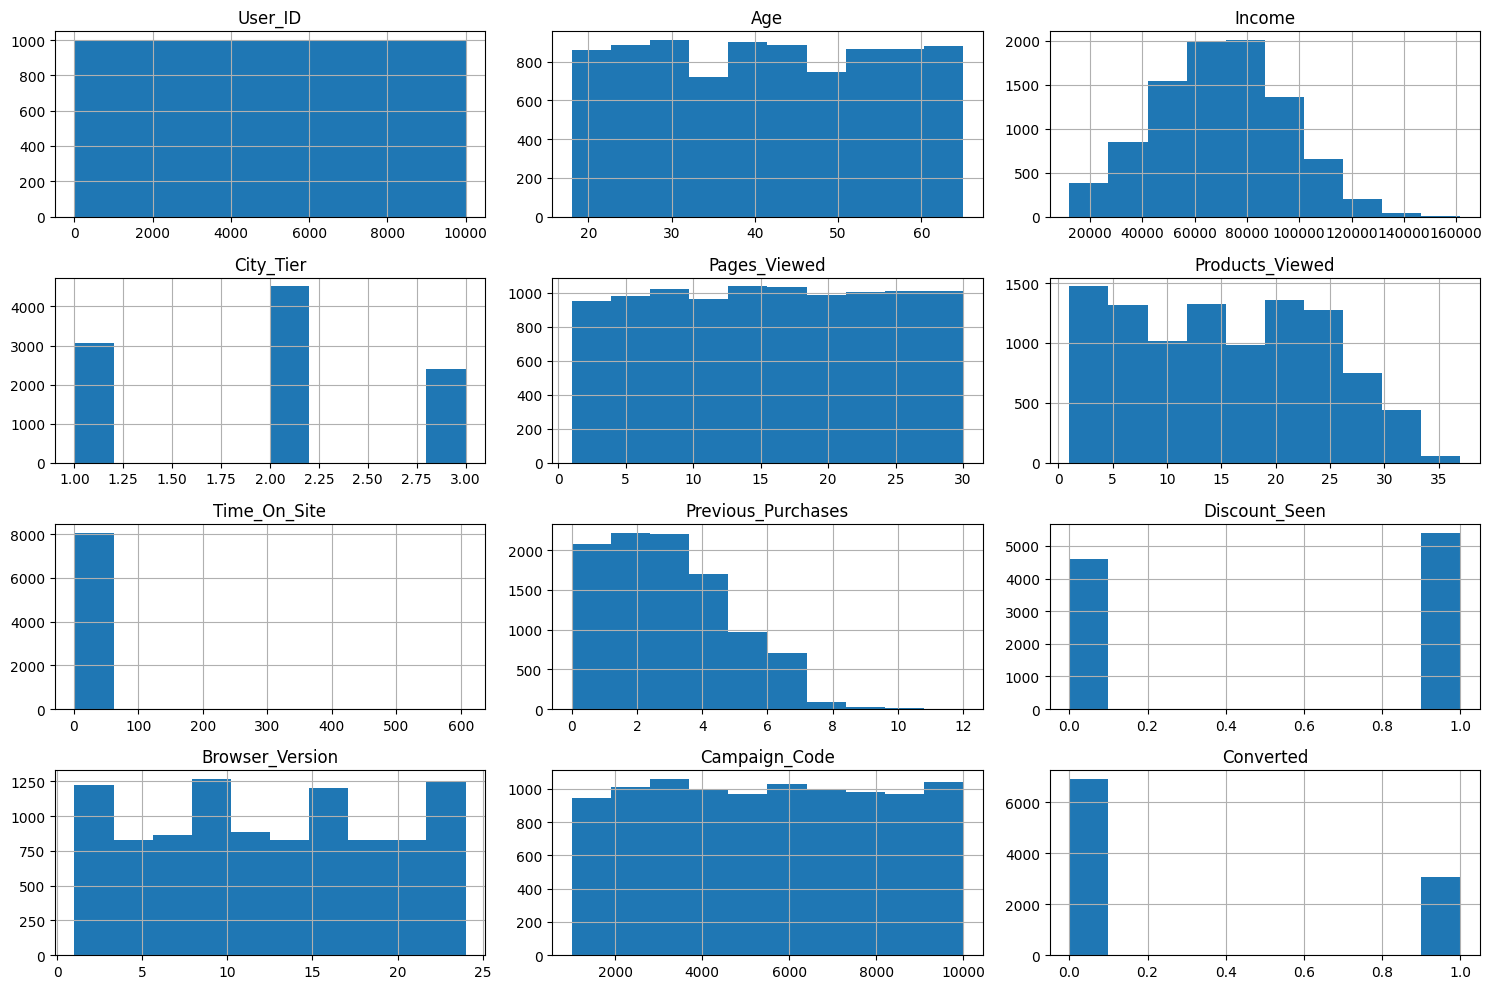

In [48]:
train.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

Conversion counts:
Converted
0    6913
1    3087
Name: count, dtype: int64

Conversion percentages:
Converted
0    0.691
1    0.309
Name: proportion, dtype: float64


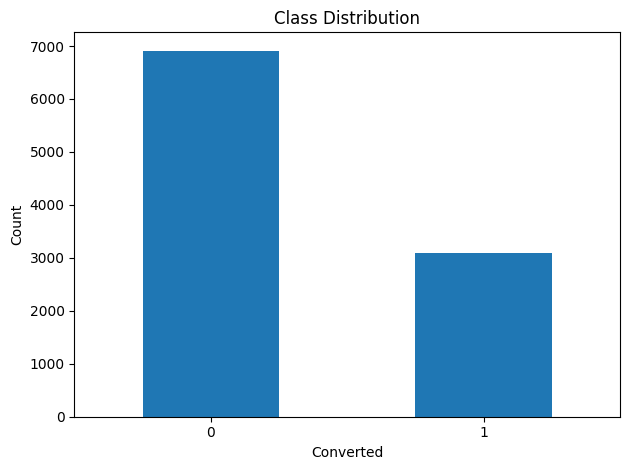

In [49]:
print("Conversion counts:")
print(train["Converted"].value_counts())
print("\nConversion percentages:")
print(train["Converted"].value_counts(normalize=True).round(3))
train["Converted"].value_counts().plot(kind="bar", title="Class Distribution")
plt.xlabel("Converted")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

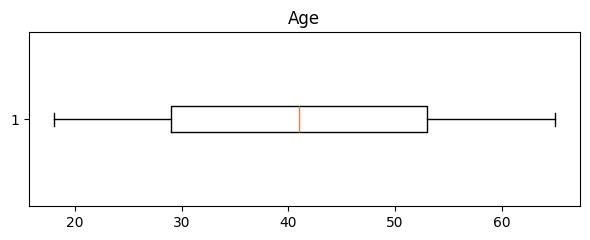

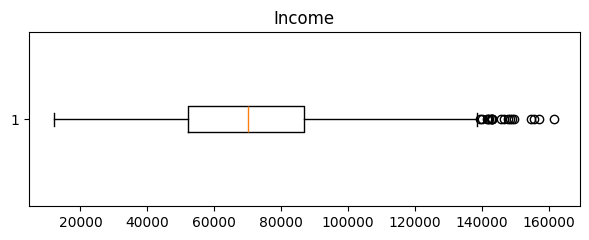

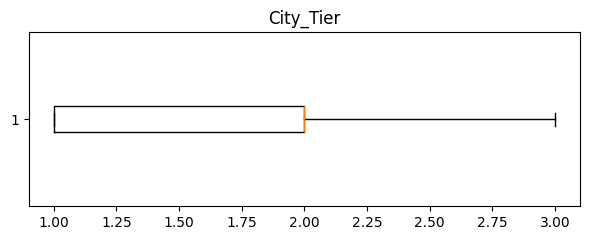

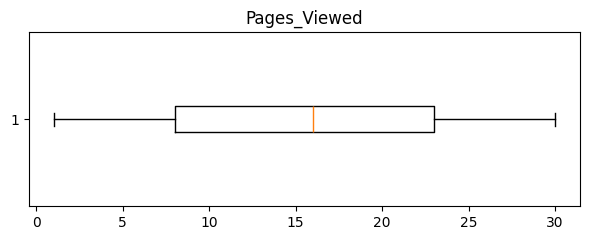

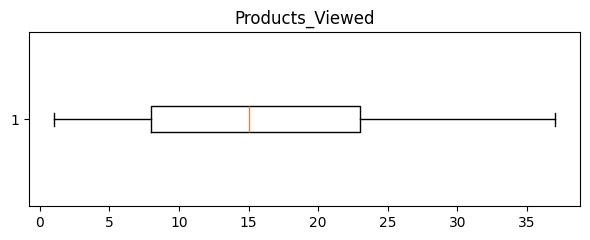

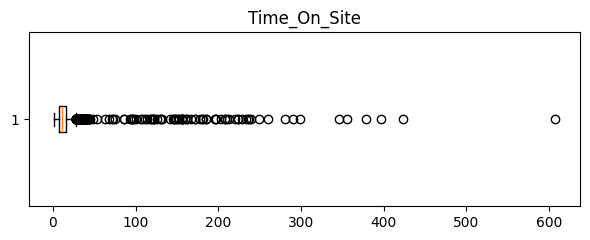

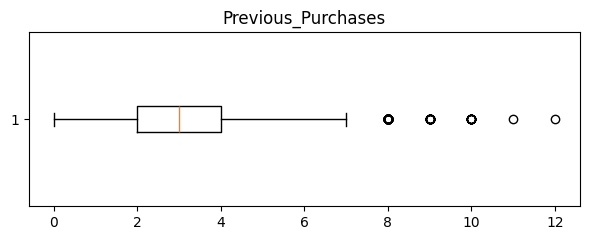

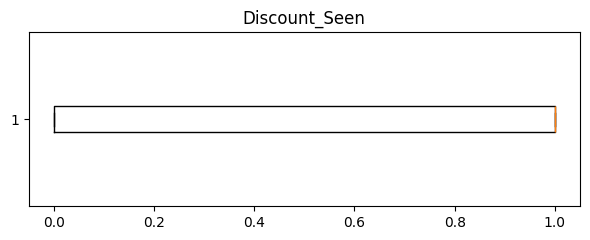

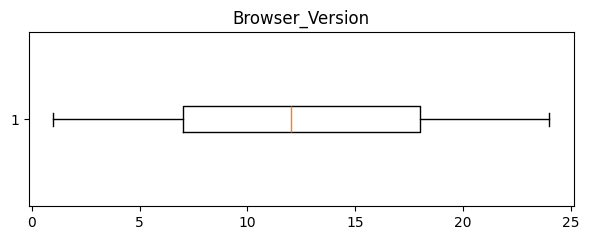

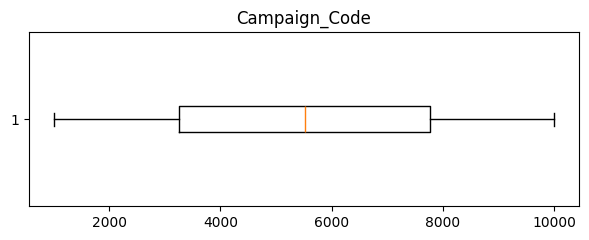

In [50]:
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [c for c in numerical_cols if c not in ["User_ID", "Converted"]]

for col in numerical_cols:
    plt.figure(figsize=(6, 2.5))
    plt.boxplot(train[col].dropna(), vert=False)
    plt.title(col)
    plt.tight_layout()
    plt.show()

In [51]:
for col in numerical_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((train[col] < lower) | (train[col] > upper)).sum()
    print(f"{col:30s}: {n_outliers} outliers")

Age                           : 0 outliers
Income                        : 19 outliers
City_Tier                     : 0 outliers
Pages_Viewed                  : 0 outliers
Products_Viewed               : 0 outliers
Time_On_Site                  : 255 outliers
Previous_Purchases            : 125 outliers
Discount_Seen                 : 0 outliers
Browser_Version               : 0 outliers
Campaign_Code                 : 0 outliers


In [52]:
cols_to_fill = ["Age", "Income", "Time_On_Site"]
for col in cols_to_fill:
    if col in train.columns:
        median_val = train[col].median() 
        train[col] = train[col].fillna(median_val)
        public_test[col]  = public_test[col].fillna(median_val)
        private_test[col] = private_test[col].fillna(median_val)

print("Missing values after imputation:")
print(train.isnull().sum())

Missing values after imputation:
User_ID               0
Age                   0
Income                0
City_Tier             0
Device_Type           0
Traffic_Source        0
Pages_Viewed          0
Products_Viewed       0
Time_On_Site          0
Previous_Purchases    0
Discount_Seen         0
Browser_Version       0
Campaign_Code         0
Converted             0
dtype: int64


In [53]:
numerical_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_cols = [c for c in numerical_cols if c not in ["User_ID", "Converted"]]

for col in numerical_cols:
    Q1    = train[col].quantile(0.25)
    Q3    = train[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    train[col] = np.clip(train[col],lower, upper)
    public_test[col]  = np.clip(public_test[col],lower, upper)
    private_test[col] = np.clip(private_test[col],lower, upper)

In [54]:
def feature_engineering(df):
    df = df.copy()
    df["Product_Page_Ratio"] = df["Products_Viewed"]/(df["Pages_Viewed"] + 1)
    df["Time_Per_Page"] = df["Time_On_Site"]/ (df["Pages_Viewed"] + 1)
    df["Purchase_Discount"] = df["Previous_Purchases"]*df["Discount_Seen"]
    df["Income_Per_Age"] = df["Income"]/(df["Age"] + 1)
    return df

train = feature_engineering(train)
public_test = feature_engineering(public_test)
private_test = feature_engineering(private_test)

print("New features added. Train shape now:", train.shape)

New features added. Train shape now: (10000, 18)


In [55]:
X_train = train.drop(columns=["Converted", "User_ID"])
y_train = train["Converted"]
X_public = public_test.drop(columns=["Converted", "User_ID"])
y_public = public_test["Converted"]
X_private = private_test.drop(columns=["User_ID"])

print("X_train shape :", X_train.shape)
print("X_public shape:", X_public.shape)
print("X_private shape:", X_private.shape)

X_train shape : (10000, 16)
X_public shape: (3000, 16)
X_private shape: (3000, 16)


In [56]:
numeric_features= X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Age', 'Income', 'City_Tier', 'Pages_Viewed', 'Products_Viewed', 'Time_On_Site', 'Previous_Purchases', 'Discount_Seen', 'Browser_Version', 'Campaign_Code', 'Product_Page_Ratio', 'Time_Per_Page', 'Purchase_Discount', 'Income_Per_Age']
Categorical features: ['Device_Type', 'Traffic_Source']


In [57]:
preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(),numeric_features),("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)])

In [58]:
model = LogisticRegression(class_weight='balanced',C=10,max_iter=5000,random_state=42)
pipeline = Pipeline(steps=[("preprocessor", preprocessor),("classifier",   model)])

In [59]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['Age','Income','City_Tier',...,'Time_Per_Page','Purchase_Discount', 'Income_Per_Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='

In [60]:
public_pred = pipeline.predict(X_public)
print(f"F1 Score on public test: {f1_score(y_public, public_pred):.4f}")
print()
print(classification_report(y_public, public_pred))

F1 Score on public test: 0.5439

              precision    recall  f1-score   support

           0       0.83      0.65      0.73      2114
           1       0.45      0.68      0.54       886

    accuracy                           0.66      3000
   macro avg       0.64      0.67      0.64      3000
weighted avg       0.72      0.66      0.68      3000



In [61]:
train_pred = pipeline.predict(X_train)
val_pred= pipeline.predict(X_public)

print(f"Train F1: {f1_score(y_train, train_pred):.4f}")
print(f"Validation F1: {f1_score(y_public, val_pred):.4f}")

print("\n Train Classification Report")
print(classification_report(y_train, train_pred))

print("\nValidation Classification Report")
print(classification_report(y_public, val_pred))

Train F1: 0.5635
Validation F1: 0.5439

 Train Classification Report
              precision    recall  f1-score   support

           0       0.83      0.66      0.74      6913
           1       0.48      0.69      0.56      3087

    accuracy                           0.67     10000
   macro avg       0.65      0.68      0.65     10000
weighted avg       0.72      0.67      0.68     10000


Validation Classification Report
              precision    recall  f1-score   support

           0       0.83      0.65      0.73      2114
           1       0.45      0.68      0.54       886

    accuracy                           0.66      3000
   macro avg       0.64      0.67      0.64      3000
weighted avg       0.72      0.66      0.68      3000



In [62]:
probs = pipeline.predict_proba(X_public)[:, 1] 
best_f1 = 0
best_threshold = 0.5
for t in np.arange(0.05, 0.95, 0.01):
    preds = (probs >= t).astype(int)
    f1= f1_score(y_public, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t
print(f"Best threshold: {round(best_threshold, 2)}")
print(f"Best F1: {round(best_f1, 4)}")

Best threshold: 0.46
Best F1: 0.5497


In [63]:
private_probs = pipeline.predict_proba(X_private)[:, 1]
private_pred = (private_probs >= best_threshold).astype(int)

print(f"Threshold used: {round(best_threshold, 2)}")
print(f"Predicted 1s: {private_pred.sum()} out of {len(private_pred)}")
print(f"Conversion rate: {private_pred.mean():.2%}")

Threshold used: 0.46
Predicted 1s: 1473 out of 3000
Conversion rate: 49.10%


In [64]:
submission = pd.DataFrame({"User_ID": private_test["User_ID"],"Converted": private_pred})
submission.to_csv("submission.csv", index=False)
print(f"Rows: {len(submission)}")
print(f"Columns: {list(submission.columns)}")
print()
print(submission.head(10))

Rows: 3000
Columns: ['User_ID', 'Converted']

   User_ID  Converted
0   103001          0
1   103002          1
2   103003          0
3   103004          1
4   103005          0
5   103006          1
6   103007          1
7   103008          0
8   103009          0
9   103010          0
